In [8]:
import numpy as np 
from utilsforecast.plotting import plot_series
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from functools import partial
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape as _mape, mase, quantile_loss, mqloss
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    SklearnModel,
)
from fpppy.models import LinearRegression

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include="number").columns] *= 100
    return df_mape

def quantile_score(df, models, q=0.5, id_col="unique_id", target_col="y"):
    df_qs = quantile_loss(df, models, q=q, id_col=id_col, target_col=target_col)
    df_qs.loc[:, df_qs.select_dtypes(include="number").columns] *= 2
    return df_qs

In [4]:
# we will be the life cycle of any forcasting performed 
gdp_df=(
    pd.read_csv("data/global_economy.csv",parse_dates=["ds"])
    [["unique_id","ds","GDP","Population"]].assign(GDP=lambda x:x["GDP"].interpolate(),Population=lambda x:x['Population'].interpolate(),y=lambda x:x['GDP']/x['Population'],)
)

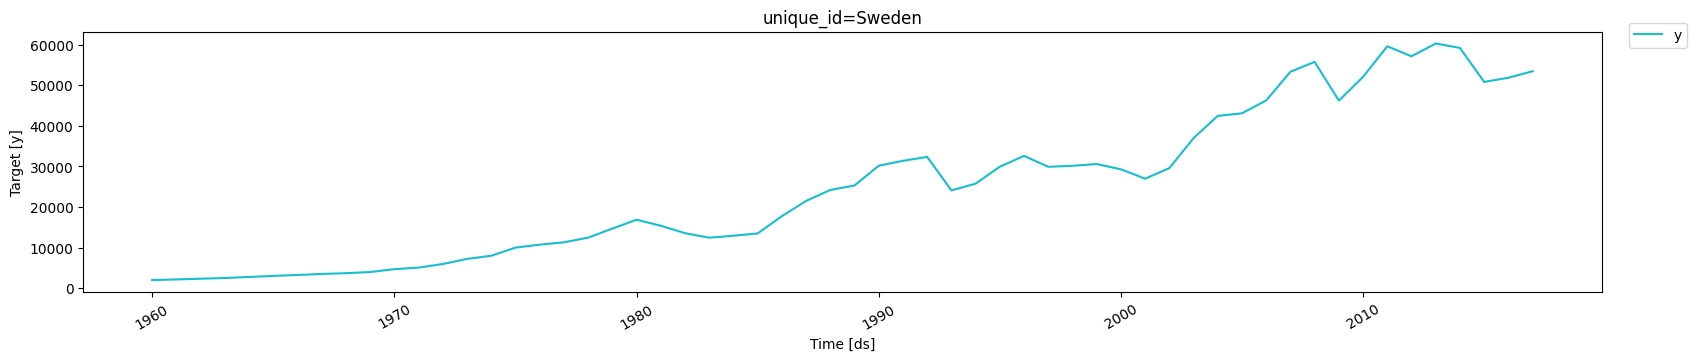

In [ ]:
#plotting the GDP per capita of Sweden.
plot_series(gdp_df,ids=["Sweden"])

In [9]:
# training our model 
sweden_df=(gdp_df.loc[lambda x:x ['unique_id']=="Sweden"]
           [["unique_id","ds","y"]])
train_features,valid_features =pipeline(sweden_df,features=[trend],freq="Y",h=3)

trend_model=SklearnModel(LinearRegression())
sf=StatsForecast(models=[trend_model],freq="Y")
sf.fit(df=train_features)



c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


StatsForecast(models=[LinearRegression])

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


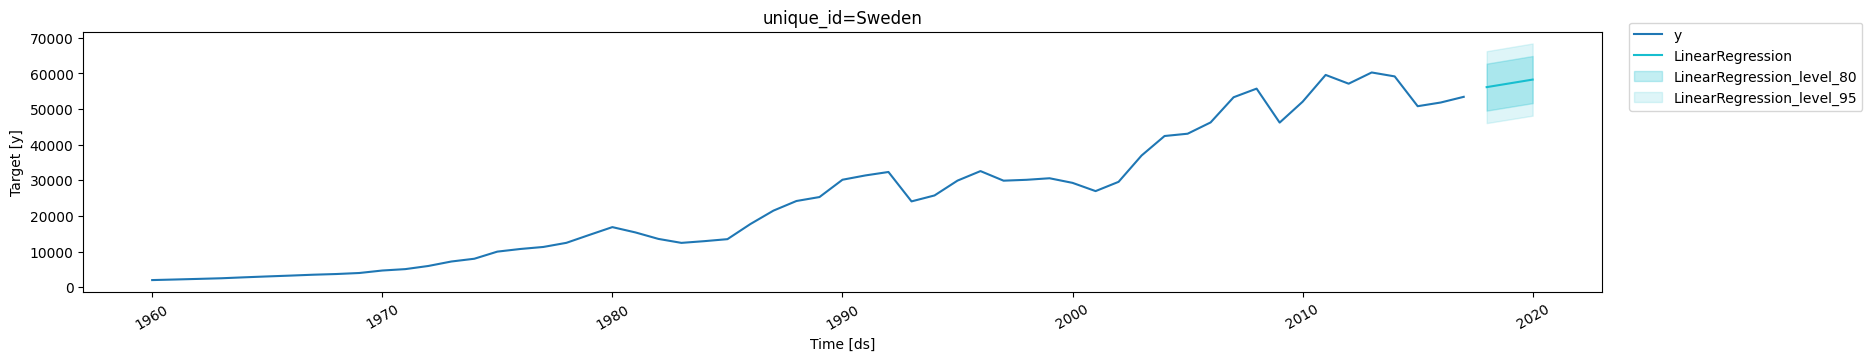

In [11]:
#producing Forcast
fcasts=sf.predict(h=3,X_df=valid_features)
model=sf.fitted_[0][0].model_['model']
fcasts=model.add_prediction_intervals(fcasts,valid_features.rename(columns={"trend":"x1"}))

#visualizing the result
plot_series(sweden_df,fcasts,ids=["Sweden"],level=[80,95])